# XBTorch::Example 07:Hardware-Aware Inference (HWA Inference)

## Introduction

In this example, we will explore hardware-aware inference capabilities provided by XBTorch. The particular example we'll focus on will be the same two-layer perceptron network using the MNIST dataset that we've seen in the previous hardware-aware training examples. Like last time, any of these parts can be extended for other applications as needed.

## Getting Started

Let's import necessary dependencies.

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import pickle
from pathlib import Path

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

from functools import partial
import torch.optim as optim

In [2]:
# XBTorch imports
import xbtorch

from xbtorch.devices import AnalyticalIdeal, AnalyticalReal, TabularAnalyticalReal, TabularCompactFeFETKriging, TabularExperimentalFemFETKriging
from xbtorch.patches import xbtorch_model

from xbtorch.nn.utils import test_classifier

from xbtorch.deployment import SimpleFixedPoint, map_random, encode_simple_binary, encode_MAO, encode_LEA1, encode_LEA2, compute_error

from nets.mlp import SimpleMLP

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


Let's fix the seed for reproducibility, and initialize network and XBTorch-specific parameters.

In [3]:
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed) # controls weight updatejump table stochasticity

# Check if CUDA is available and select the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Initialize XBTorch

The XBTorch module that handles hardware-aware inference is the `GenericAccelerator` primitive defined in the `xbtorch.deployment` module. 

An accelerator defines the underlying number of available devices and their properties (such as conductances). Given a pre-trained solution, it also handles the encoding from weights to conductances, mapping from conductances to actual physical devices. During inference, all vector-matrix multiplications happen in the analog domain on the simulated accelerator, while all other functions happen in the digital domain. 

At the very least, an inference accelerator should implement these analog-to-digital and digital-to-analog transfer functions. Custom presets can be created by inheriting from the `GenericAccelerator` primitive. A simple accelerator preset that XBTorch provides out-of-the-box is `SimpleFixedPoint`. In this example, we will use this preset and observe how various accelerator parameters could impact the network performance of a previously trained neural network (the same HWA trained network from our HWA training examples).

In [4]:
xb_size = (2500, 2500)
g_min = 133
g_max = 233
read_noise = 10
write_noise = 50
weight_encoding_scheme = encode_simple_binary
mapping_scheme = map_random
output_polling_mode = "avg"
adc_precision = dac_precision = 8

In the cell above, we initialize various XBTorch parameters pertaining to hardware-aware inference. Here's a quick summary of what everything means:

| Parameter    | Purpose |
| -------- | ------- |
| `xb_size`  | How many devices does our accelerator support?    |
| `g_min` | The minimum conductance, in $\mu S$, of devices in the accelerator      |
| `g_max`    | The maximum conductance, in $\mu S$, of devices in the accelerator    |
| `read_noise`    | The uniform noise, in $\mu S$, injected to all reads on the accelerator |
| `write_noise`    | The zero mean gaussian noise, in $\mu S$, injected to all writes on the accelerator |
| `weight_encoding_scheme`    | The scheme to use for encoding weights into device conductances. Advanced schemes are covered in the fault tolerance example notebook  |
| `mapping_scheme`    | The scheme to use for mapping device conductance matrices to actual device locations within the accelerator. Advanced schemes are covered in the fault tolerance example notebook |
| `output_polling_mode`    | If there are multiple mapped instances for a network layer, how should output currents be gathered? Advanced schemes are covered in the fault tolerance example notebook |
| `adc_precision`, `dac_precision`    | The fixed point precision of inputs and outputs to/from mapped layers |

For more details on the API, view the full XBTorch documentation.

In [5]:
inference_accelerator = SimpleFixedPoint(g_min=g_min, 
                                         g_max=g_max, 
                                         adc_bits=adc_precision, 
                                         dac_bits=dac_precision, 
                                         read_noise=read_noise, 
                                         write_noise=write_noise, 
                                         xb_size=xb_size,
                                         weight_encoding_scheme=weight_encoding_scheme, 
                                         xb_mapping_scheme=mapping_scheme)

We can now initialize XBTorch. Recall that if a parameter is not provided, default values are utilized. The reader is directed to `XBParams.__init__()` for the underlying implementation.

In [6]:
wage_params = { "wl_weight": 2, # 2 = ternary weights
                "wl_grad": 8,
                "wl_activation": 8,
                "wl_error": 8,
                "rounding_weight" : "nearest",
                "rounding_activation" : "nearest",
                "rounding_grad" : "nearest",
                "rounding_error" : "nearest",
               }

# Init xbtorch
xbtorch.initialize(pytorch_device=device,
                   inference_accelerator=inference_accelerator,
                   wage_quantize=True, # since the trained solution utilized wage quantization
                   wage_params=wage_params
                   )

## Prepare the dataset

We can now prepare the dataset for our neural network.

In [7]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True, generator=torch.Generator(device=device), num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, generator=torch.Generator(device=device), num_workers=4)

## Prepare the model

We simply instantiate and load the state dictionary of our HWA pre-trained simple 2-layer perceptron network. 

In [8]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

# Create Model
model = SimpleMLP(input_size, hidden_size, output_size).to(device)
model = xbtorch_model(model)

# Override state dict. 
# If we had dumped the final state_dict directly, model.load_state_dict(torch.load(..)) could be used instead
with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)
    
epoch = -1 # load last epoch's weights

for name, param in model.named_parameters():
    param.data = torch.from_numpy(full_weights_hwa[name][epoch, ...]).float()

## Baseline performance

We can firstly compute the baseline test accuracy of our network. This is the accuracy before activating the inference accelerator (i.e. all computations of the network happen without the accelerator primitive's intervention).

In [9]:
baseline_acc, _ = test_classifier(test_loader, model, device)

## Hardware-aware Inference performance

**Step 1:** If the patching was successful, XBTorch adds a convenient `xb_eval(enable=True)` method on to the model. We can call this method appropriately to enable or disable the inference accelerator's intervention during the model's forward pass. The first step is to enable this. 

**Step 2:** The second step is to clear the inference accelerator of any previous written devices. This is equivalent to resetting any previously written devices. While this step is technically optional, it is recommended since it ensures that all initialized devices on the accelerator are ones that participate in the most recent mapping of a neural network. 

**Step 3:** The final step is to initialize array mappings via `initialize_array_mappings()`. This is another helper method that gets added upon successful patching. It handles the mapping of conductance matrices (which are pre-encoded during initialization) to locations within the accelerator. 

NOTE: Due to randomness (because of read and write noise), one may want to gauge HWA inference performance across multiple iterations. Higher the noise, higher should be these iterations, so as to sufficiently capture the noise.

In [10]:
iterations = 10

# Step 1: Enable evaluation on the inference accelerator
model.xb_eval()

hwa_accs = np.zeros((iterations,))

for i in range(iterations):
    print(f"\nIteration {i+1}")
    # Step 2: Clear previous mappings
    inference_accelerator.initialize_chip()
    # Step 2: Initialize array mappings
    model.initialize_array_mappings(output_polling_mode=output_polling_mode, 
                                    additional_args={}, 
                                    existing_mappings=[]
                                   )

    # Step 3:  Test the performance like before!
    acc, _ = test_classifier(test_loader, model, device)
    hwa_accs[i] = acc


Iteration 1

Iteration 2

Iteration 3

Iteration 4

Iteration 5

Iteration 6

Iteration 7

Iteration 8

Iteration 9

Iteration 10


In [11]:
np.average(hwa_accs), np.std(hwa_accs)

(np.float64(85.04299999999999), np.float64(3.929114531290733))

We see that despite HWA-training, our network's performance significantly drops when we consider non-idealities at the level of the inference accelerator. In the current setting, the primary reason for this drop is the degree of read and write noise. If those were lower, our network's performance would be better, and conversely if those were higher, our network's performance would be even worse.

Feel free to try various values for the read and write noise, and observe how the network's performance changes. 

## Visualizing the Inference Accelerator

XBTorch also provides a helpful utility for visualizing the current state of the inference accelerator. Note that read noise is injected everytime the state of our accelerator is read, and so multiple calls would produce different results based on the specified level of read noise.

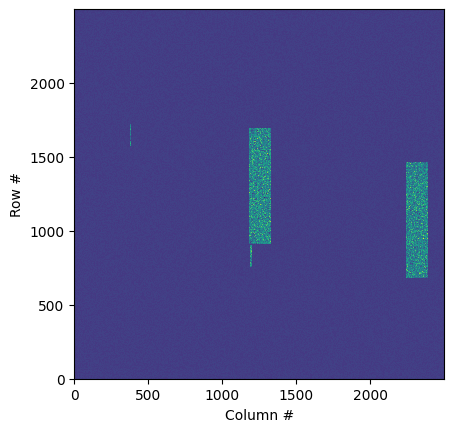

In [12]:
full_read = inference_accelerator.plot_array()

The generated heatmap shows the conductances of all 2500 $\times$ 2500 devices in our simulated inference accelerator. The large contiguous blocks correspond to the first fully-connected layer of our neural network, which had dimensions 784 $\times$ 150, while the smaller contiguous blocks correspond to the second fully-connected layer of our neural network, which had dimensions 150 $\times$ 10.

The reason why we have 2 device blocks for each weight matrix is because we are using a differential encoding scheme, which encodes a weight matrix $W$ into 2 conductance matrices $G_{pos}$ and $G_{neg}$. See `encode_simple_binary()` for more details on that.

If we wanted to visualize specific layer instances, it would be helpful to know where a particular layer gets mapped to. XBTorch provides a convenient method to accomplish this.

## Visualizing specific layers

Let's say we wanted to visualize mappings for the first fully connected layer's $G_{pos}$ matrix.

In [13]:
model

SimpleMLP(
  (model): Sequential(
    (0): WAGEQuantizer()
    (1): Linear(in_features=784, out_features=150, bias=False)
    (2): ReLU()
    (3): WAGEQuantizer()
    (4): Linear(in_features=150, out_features=10, bias=False)
    (5): WAGEQuantizer()
  )
)

We can use the `get_array_mappings()` helper method to extract the underlying array mappings for each layer. This is another helper method that gets added to the model on successful patching. The output is a list of dictionaries, where the i-th element corresponds to the i-th layer, and dictionary keys indicate the matrix type (based on the encoding scheme).

In [14]:
mappings = model.get_array_mappings()
mappings

[{'Gpos': [(2242, 681)], 'Gneg': [(1178, 911)]},
 {'Gpos': [(375, 1576)], 'Gneg': [(1189, 753)]}]

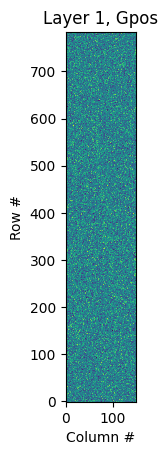

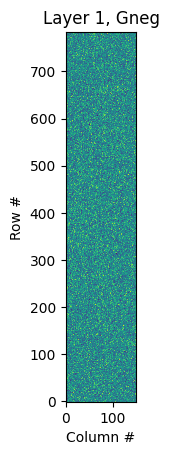

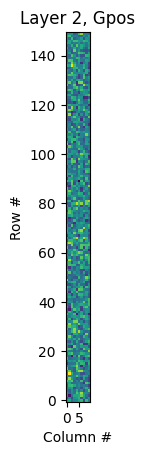

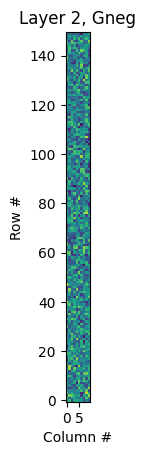

In [15]:
layer_dims = {0: [150, 784], 1: [10, 150]}

for layer_idx in [0, 1]:
    for g_string in ["Gpos", "Gneg"]:

        title = f"Layer {layer_idx+1}, {g_string}"
        
        row_start, col_start = mappings[layer_idx][g_string][0]
        row_count, col_count = layer_dims[layer_idx] # layer dims
        
        data = inference_accelerator.plot_array(row_start, row_count, col_start, col_count, title=title) # could be logged if necessary

Internally, the `plot_array()` method performs read operations on the array. For a given layer, we can also visualize the underlying conductance distribution by doing explicit reads directly.

In [16]:
# Save for plotting later
data_dict = {"Gmap": full_read.numpy(),
            "mappings": mappings,
            "layer_dims": layer_dims}

output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)
model_name = f"{output_path}/hwa_inference_mlp_hwa_gmap_example.pkl"
with open(model_name, "wb") as f:
    pickle.dump(data_dict, f)

In [17]:
# extract true conductance values for layer 1 (for coloring read back values appropriately)
true_Gpos, true_Gneg = encode_simple_binary(inference_accelerator, model.model[1].weight.data)

# read back actual values for layer 1 G_pos from the inference accelerator (these are actual devices) 
layer_idx = 0
row_start, col_start = mappings[layer_idx]["Gpos"][0]
row_count, col_count = layer_dims[layer_idx]
read_values = inference_accelerator.read_chip(row_start, 
                                              row_count, 
                                              col_start, 
                                              col_count)

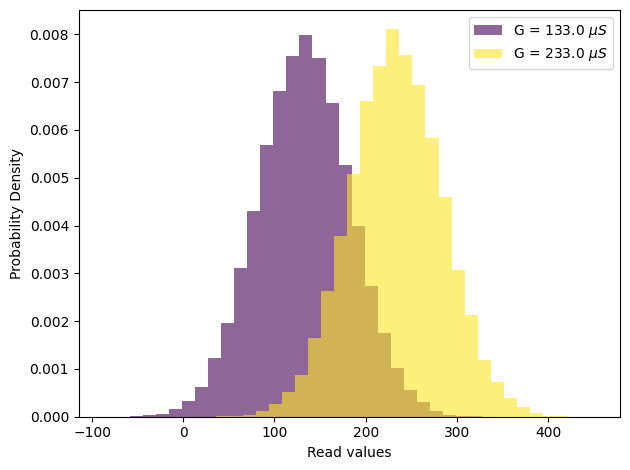

In [18]:
def plot_histogram(read_values, true_values):
    plt.figure()
    
    # Get unique values in true_values
    unique_values = np.unique(true_values)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_values)))

    for val, color in zip(unique_values, colors):
        subset = read_values[true_values == val]
        plt.hist(subset, bins=30, density=True, alpha=0.6, color=color, label=f'G = {val} $\mu S$')

    plt.xlabel("Read values")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_histogram(read_values, true_Gpos[0])

In [19]:
# Save for plotting later, can be skipped
data_dict = {"read_values": read_values.numpy(),
            "true_Gpos": true_Gpos[0].numpy()}

output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)
model_name = f"{output_path}/hwa_inference_mlp_hwa_layer{layer_idx}_hist_example.pkl"
with open(model_name, "wb") as f:
    pickle.dump(data_dict, f)

## Impact of ADC/DAC Quantization

We can use the current setup to investigate the impact of various accelerator parameters on network performance. In the previous example, we saw one such case where the read and write noise sources caused a performance gap in the network performance. We could also do things like investigate the impact of ADC/DAC quantization.

In [20]:
adc_dac_quantizations = np.arange(1, 8, 1)
iterations = 10
adc_dac_accs = np.zeros((len(adc_dac_quantizations), iterations))

for quant_idx, quant in enumerate(adc_dac_quantizations):
    # Initialize the inference accelerator
    inference_accelerator = SimpleFixedPoint(g_min=g_min, 
                                             g_max=g_max, 
                                             adc_bits=quant, # use sweep value
                                             dac_bits=quant, # use sweep value
                                             read_noise=read_noise, # no read noise
                                             write_noise=write_noise, # no write noise 
                                             xb_size=xb_size,
                                             weight_encoding_scheme=weight_encoding_scheme, 
                                             xb_mapping_scheme=mapping_scheme)
    # Initialize XBTorch
    xbtorch.initialize(pytorch_device=device,
                   inference_accelerator=inference_accelerator,
                   wage_quantize=True, # since the trained solution utilized wage quantization
                   wage_params=wage_params
                   )

    # Initialize the chip and the mappings
    inference_accelerator.initialize_chip()

    # Create, patch, and load the model's state dictionary (same as above)
    model = SimpleMLP(input_size, hidden_size, output_size).to(device)
    model = xbtorch_model(model)
    
    with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
        full_weights_hwa = pickle.load(f)
        
    epoch = -1 
    
    for name, param in model.named_parameters():
        param.data = torch.from_numpy(full_weights_hwa[name][epoch, ...]).float()

    # Initialize array mappings
    model.initialize_array_mappings(output_polling_mode=output_polling_mode, 
                                    additional_args={}, 
                                    existing_mappings=[]
                                   )

    # Test the performance like before!
    model.xb_eval(enable=True)
    for iteration in range(iterations):
        acc, _ = test_classifier(test_loader, model, device)
        adc_dac_accs[quant_idx, iteration] = acc

In [21]:
def plot_adc_dac_accuracies(quantizations, accuracies, baseline_acc):
    plt.figure()
    plt.bar([str(q) for q in quantizations], np.average(accuracies, axis=1), color='skyblue', edgecolor='black')
    plt.xlabel('ADC/DAC Bit Precision')
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.axhline(baseline_acc, label="Ideal Baseline", color='black',)
    plt.legend()
    plt.show()

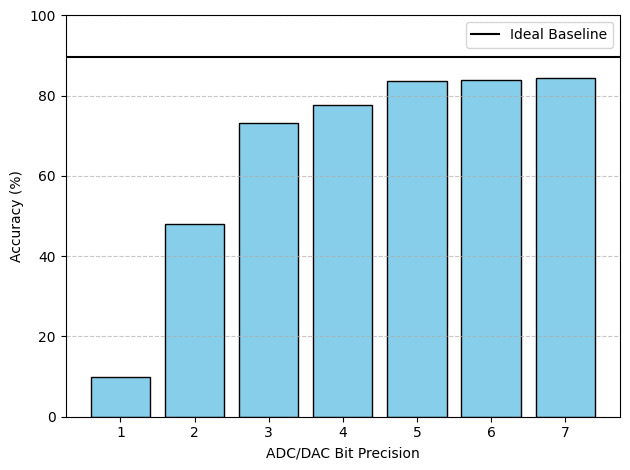

In [22]:
plot_adc_dac_accuracies(adc_dac_quantizations, adc_dac_accs, baseline_acc)

In [23]:
# Save data for later plotting
# Save for plotting later, can be skipped
data_dict = {"adc_dac_quantizations": adc_dac_quantizations,
            "adc_dac_accs": adc_dac_accs,
            "baseline_acc": baseline_acc}

output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)
model_name = f"{output_path}/hwa_inference_mlp_hwa_adcdac_quant_example.pkl"
with open(model_name, "wb") as f:
    pickle.dump(data_dict, f)

## Conclusion

We went through the complete hardware-aware inference workflow in XBTorch. We saw an example of how an inference accelerator can be instantiated and utilized to benchmark the impact of various parameters on the neural network's performance. We also saw how to visualize the state of the underlying accelerator, as well as investigate mappings of individual layers. In the next example, we will focus on how usage of the inference accelerator can be augmented to implement advanced fault-tolerance schemes.